##### Name - Ahaan Tagare
##### Student ID - 33865799 
##### ARTIFICIAL INTELLIGENCE (2024-25) 

### Comparative Evaluation of Machine Learning and Deep Learning Models for resume dataset

#### Abstract

This project explores the classification of resumes into different job categories using a combination of machine learning and deep learning techniques. The dataset comprises resumes categorized into various fields like Information Technology, Finance, and Healthcare.

The initial phase involves data preprocessing, including text cleaning, tokenization, and TF-IDF vectorization. Subsequently, traditional machine learning models such as Decision Trees, Random Forests, and Logistic Regression are evaluated and compared.

The core of the project lies in the implementation and comparison of deep learning architectures. This includes:

Feedforward Neural Networks: A multi-layer perceptron is designed and tuned for optimal hyperparameters.
Recurrent Neural Networks (LSTM): An LSTM model is employed to capture sequential information within the text data.
Convolutional Neural Networks (CNN): A CNN model is utilized to extract relevant features from the text.
Finally, an enhanced feedforward neural network with deeper layers and dropout regularization is developed.

The performance of each model is assessed based on metrics such as accuracy, precision, recall, and F1-score. The results demonstrate the effectiveness of deep learning models, particularly the enhanced feedforward network and the LSTM model, in achieving high accuracy in resume categorization. This research provides valuable insights into applying deep learning techniques for text classification tasks in the recruitment domain.

#### Introduction

This project focuses on building a robust resume categorization system. We utilize a combination of machine learning and deep learning algorithms to classify resumes into various job categories. The dataset consists of a diverse collection of resumes spanning various domains. The project explores the effectiveness of different models, including traditional machine learning algorithms and deep learning architectures such as feedforward neural networks, recurrent neural networks (LSTMs), and convolutional neural networks (CNNs). Through rigorous evaluation and hyperparameter tuning, we aim to identify the most effective model for accurate and efficient resume classification.

#### Overview of Libraries and Their Functions

A number of libraries necessary for data analysis, machine learning, and visualization are imported by this code. Numpy and pandas deal with numerical data and structured datasets, respectively, while re is used for text manipulation using regular expressions. Seaborn and matplotlib.pyplot offer tools for building and modifying visuals, which facilitate data analysis and presentation. Warnings controls warning messages, and missingno helps visualize trends in missing data. Tensorflow makes it possible to create deep learning models, whereas nltk is essential for natural language processing. Last but not least, time measures how long operations take, enabling performance evaluation.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import nltk
import tensorflow as tf
import time

Tokenizing text, eliminating stopwords, and stemming words are all crucial aspects of text preprocessing that NLTK offers capabilities for. For classification tasks, Scikit-learn provides a variety of machine learning models, including Decision Trees, Random Forest, Logistic Regression, and SVM. It also provides tools for data splitting, TF-IDF feature extraction, and model evaluation using measures like accuracy, precision, and recall. Word frequencies in text can be visually represented with WordCloud. Using sophisticated methods like bidirectional layers and attention mechanisms, TensorFlow and Keras are used to construct deep learning models, such as CNNs, LSTMs, GRUs, and sequential networks. In order to optimize model training, the code additionally makes use of callbacks for learning rate lowering and early termination.

In [2]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
from wordcloud import WordCloud
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding, Bidirectional, GlobalAveragePooling1D, Conv1D, MaxPooling1D, Flatten, BatchNormalization, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.metrics import AUC
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


#### Dataset Exploration and Insights
Downloading crucial NLTK datasets, including the "punkt" tokenizer and the list of "stopwords," which are required for text processing jobs, is part of this step. After that, a Pandas DataFrame is loaded with the dataset, "Resume.csv," for examination and analysis. Following that, 20% of the data is set aside for testing, and the remaining data is divided into training and test sets. Using stratification based on the 'Category' column, this split is carried out in a way that maintains the category distribution in both groups. Lastly, the test data is stored for later use in model evaluation in a distinct CSV file named "test_resume_data.csv."


In [3]:
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [4]:
# Load and explore the dataset
data = pd.read_csv('Resume.csv')

In [5]:
# Split data into training and test sets
resume_data, resume_test_data = train_test_split(data, test_size=0.20, stratify=data['Category'], random_state=42)

In [6]:
# Save the test data
resume_test_data.to_csv('test_resume_data.csv', index=False)

In order to understand the structure and content of the loaded dataset, this step of the procedure investigates it. There are 1,987 entries in the dataset, and it has four columns: "ID," "Resume_str," "Resume_html," and "Category." Each resume is uniquely identified by its 'ID' column, while its plain text content is contained in 'Resume_str' and its HTML version is contained in 'Resume_html'. The categorization or job category of each resume, such as finance, banking, or human resources, is indicated in the Category column. There are no missing values in the dataset, and all three object-type columns and one integer column are correctly filled with the appropriate data types. This provides an excellent summary of the data prior to additional processing and analysis.

In [7]:
# Explore dataset
print(resume_data.head())

            ID                                         Resume_str  \
70    20993320           HR COORDINATOR         Summary     Fr...   
2203  33872500           FINANCIAL INSTITUTIONS EXAMINER      ...   
982   15145575           IT SUPPORT OFFICER           Executiv...   
1518  11441764           FINANCE MANAGER         Summary     P...   
11    11480899           HR MANAGER         Summary      Human...   

                                            Resume_html Category  
70    <div class="fontsize fontface vmargins hmargin...       HR  
2203  <div class="fontsize fontface vmargins hmargin...  BANKING  
982   <div class="fontsize fontface vmargins hmargin...      BPO  
1518  <div class="fontsize fontface vmargins hmargin...  FINANCE  
11    <div class="fontsize fontface vmargins hmargin...       HR  


#### Dataset  

The dataset https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset contains 1987 entries and 4 columns. It includes an ID column, which is an integer identifier for each record, and it has no missing values. The Resume_str column stores the resumes in plain text format, while the Resume_html column contains the resumes formatted in HTML, both of which are stored as object data types. The final column, Category, represents the classification or category associated with each resume, such as job roles or types. All columns have non-null entries, meaning there are no missing values. The dataset has a total shape of 1987 rows and 4 columns and takes up approximately 77.6 KB of memory, indicating it is a manageable size for processing and

In [8]:
print(resume_data.info())
print(resume_data.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1987 entries, 70 to 2020
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           1987 non-null   int64 
 1   Resume_str   1987 non-null   object
 2   Resume_html  1987 non-null   object
 3   Category     1987 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.6+ KB
None
(1987, 4)


In [9]:
print(resume_data['Category'].value_counts())

Category
INFORMATION-TECHNOLOGY    96
BUSINESS-DEVELOPMENT      96
CHEF                      94
ENGINEERING               94
FINANCE                   94
ACCOUNTANT                94
FITNESS                   94
ADVOCATE                  94
SALES                     93
AVIATION                  93
HEALTHCARE                92
CONSULTANT                92
BANKING                   92
CONSTRUCTION              90
PUBLIC-RELATIONS          89
HR                        88
DESIGNER                  86
ARTS                      82
TEACHER                   82
APPAREL                   78
DIGITAL-MEDIA             77
AGRICULTURE               50
AUTOMOBILE                29
BPO                       18
Name: count, dtype: int64


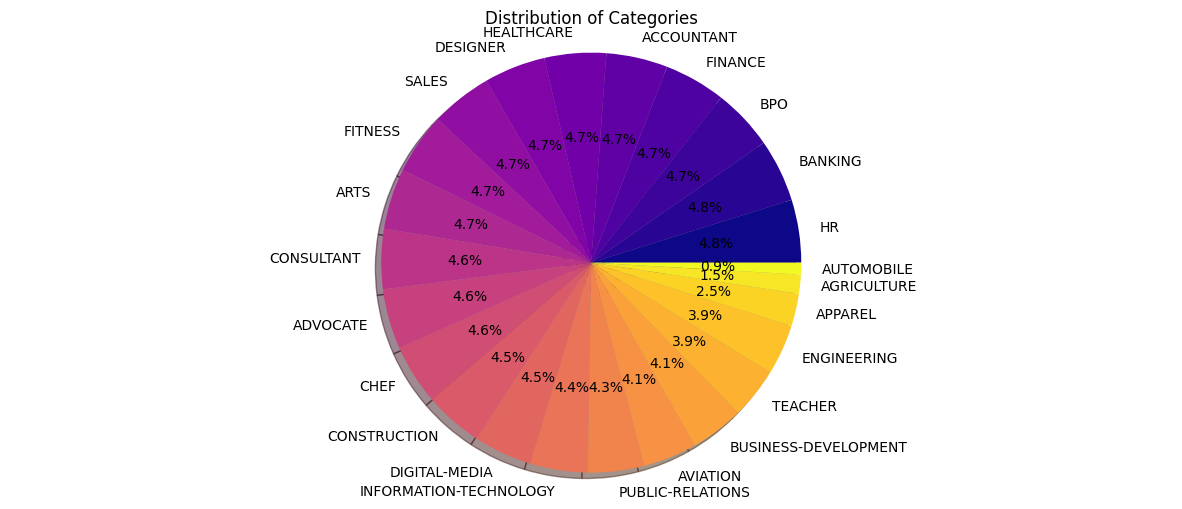

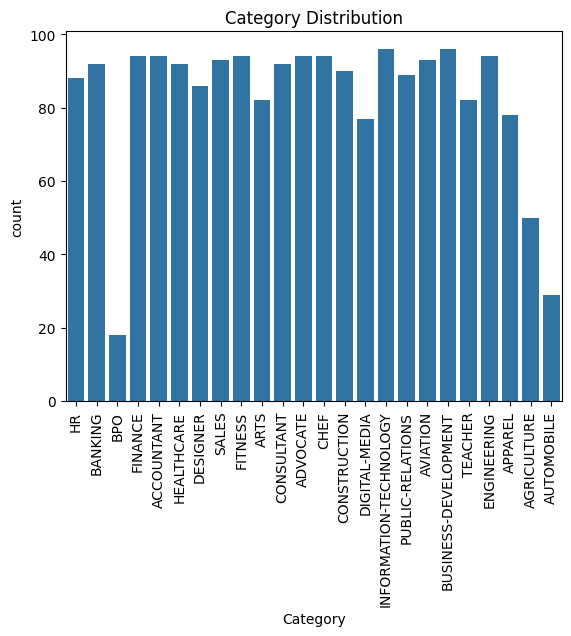

In [10]:
# Visualize the distribution of categories
plt.figure(figsize=(15, 6))
counts = resume_data['Category'].value_counts()
labels = resume_data['Category'].unique()

plt.pie(counts, labels=labels, autopct='%1.1f%%', shadow=True, colors=plt.cm.plasma(np.linspace(0, 1, len(labels))))
plt.title('Distribution of Categories')
plt.axis('equal')
plt.show()

sns.countplot(x=resume_data['Category'])
plt.xticks(rotation=90)
plt.title('Category Distribution')
plt.show()

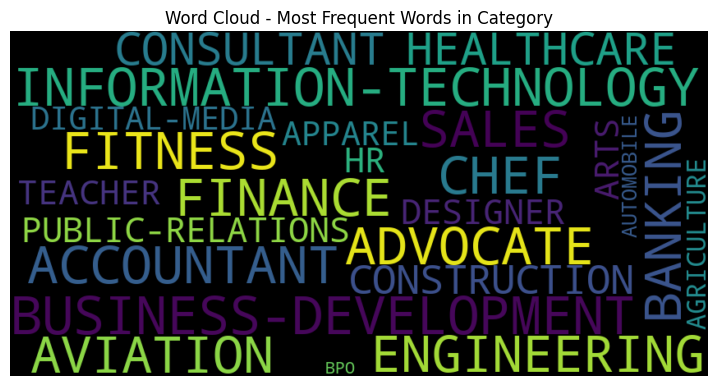

In [17]:
# Combine text from category column for word cloud
combined_text = ' '.join(resume_data['Category'])
word_counts = Counter(combined_text.split())
wordcloud = WordCloud(width=850, height=420, background_color='black').generate_from_frequencies(word_counts)

plt.figure(figsize=(9, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Frequent Words in Category')
plt.show()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


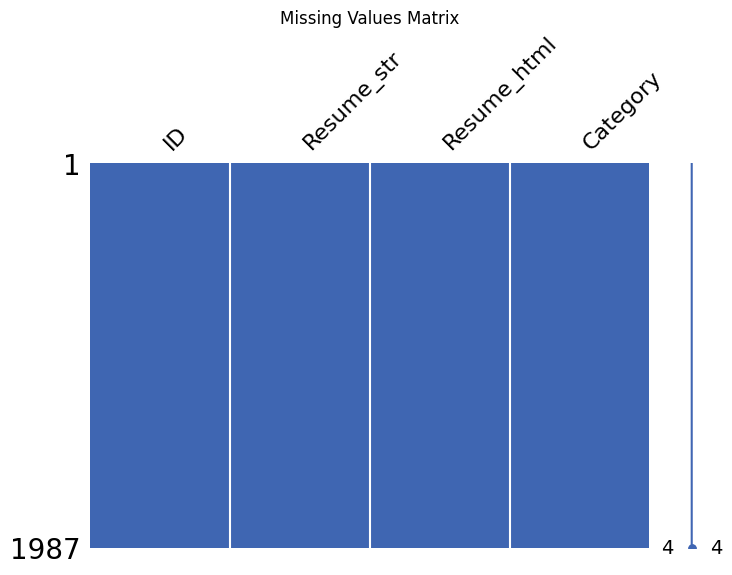

In [12]:
# Check for missing values
missing_values = resume_data.isnull().sum()
print(missing_values)


msno.matrix(resume_data, figsize=(8, 5), color=(0.25, 0.4, 0.7))
plt.title('Missing Values Matrix')
plt.show()

#### Data Preprocessing and Label Encoding

Using the.apply() method, the resume_cleaning function is first applied to the dataset's 'Resume_str' column. By eliminating HTML elements, non-alphabetic characters, and stopwords, and then stemming the words, this guarantees that all resume text data is cleaned. 'Cleaned_Resume' is a new column that contains the cleaned content. To guarantee that only legitimate data is kept after cleaning, rows with empty 'Cleaned_Resume' values are filtered out. Furthermore, the original 'Resume_str' and 'Resume_html' columns are removed because they are no longer required, leaving only the target category and the cleaned resume text.

In [13]:
# Text preprocessing function
def resume_cleaning(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    words = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    stemmer = PorterStemmer()
    stemmed_words = [stemmer.stem(word) for word in filtered_words]
    return ' '.join(stemmed_words)

The target labels, which represent the resume categories, are then translated into numeric values using LabelEncoder. This is a crucial stage for machine learning models, which often require numerical values for target variables. The encoded labels are in the 'Category' column. The dataset is then split between training and validation sets using train_test_split. This method uses 20% of the data for model evaluation and 80% of the data for model training. For reproducibility, a fixed random seed (random_state=42) is used, and the split is performed while ensuring that the distribution of categories in both sets is similar (stratify). The input characteristics and related labels are therefore prepared for model evaluation and training.



In [14]:
# Apply cleaning
data['Cleaned_Resume'] = data['Resume_str'].apply(resume_cleaning)

# Remove empty rows and Encode target labels
data = data[data['Cleaned_Resume'] != '']
data = data.drop(['Resume_str', 'Resume_html'], axis=1)

encoder = LabelEncoder()
data['Category'] = encoder.fit_transform(data['Category'])

# Split the data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(data['Cleaned_Resume'], data['Category'], test_size=0.20, stratify=data['Category'], random_state=42)

In [18]:
# Visualize category distribution 
train_counts = y_train.value_counts()
valid_counts = y_valid.value_counts()

distribution_df = pd.DataFrame({
    'Training': train_counts,
    'Validation': valid_counts
}).fillna(0)

distribution_df = distribution_df.sort_values(by='Training', ascending=False)

plt.figure(figsize=(12, 6))
distribution_df.plot(kind='bar', stacked=True, color=['#4caf50', '#2196f3'], edgecolor='black', width=0.8)
plt.title('Category Distribution in Training and Validation Sets', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Dataset', fontsize=10)
plt.tight_layout()
plt.show()

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

<Figure size 1200x600 with 0 Axes>

#### TF-IDF Vectorization and One-Hot Encoding

The text data is ready for model training thanks to this little piece of code. The text resumes are first converted into numerical representations using TF-IDF vectorization. In order to do this, a lexicon of the most common words must be created, and each word must be given a weight according to its significance and rarity in the documents. To increase efficiency, the max_features option restricts the vocabulary size while the stop_words parameter eliminates popular English words. The goal labels (job categories) are then converted into a format appropriate for neural network training using one-hot encoding. Each category in one-hot encoding is represented by a vector that has a single '1' at the category-corresponding index and a '0' elsewhere. 

In [ ]:
# Vectorize text using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=800)
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)


num_classes = len(np.unique(y_train))
y_train_nn = to_categorical(y_train, num_classes)
y_valid_nn = to_categorical(y_valid, num_classes)

#### Machine Learning Models: Performance Metrics








The code that is provided assesses how well various machine learning models perform on a certain dataset. Using the training dataset (X_train, y_train), the evaluate_model function trains a model and makes predictions on a validation dataset (X_valid). The predictions and real labels are then used to calculate important performance metrics like accuracy, precision, recall, and F1-score. By taking into account both accurate predictions and the ratio of false positives to false negatives, these metrics offer information about how effectively the model works.

In [ ]:
# evaluate a model and compute performance metrics
def evaluate_model(model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_valid)  # Predict on validation set
    
   
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_valid, y_pred, average='weighted')
    f1 = f1_score(y_valid, y_pred, average='weighted')
    
    
    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred, zero_division=0))
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

Various machine learning models, including Decision Tree, Random Forest, Logistic Regression, and others, are initialized and evaluated using the evaluate_model function in the second section of the code. The outcomes, which include classification reports for in-depth performance analysis, are shown in a condensed style and saved in a dictionary. This makes it possible to compare various models in order to identify the method that performs the best on the dataset.

### Key Machine Learning Metrics and Formulas

#### 1. Accuracy
$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$  
Where:
- $TP$: True Positives  
- $TN$: True Negatives  
- $FP$: False Positives  
- $FN$: False Negatives  

---

#### 2. Precision
$Precision = \frac{TP}{TP + FP}$

---

#### 3. Recall (Sensitivity)
$Recall = \frac{TP}{TP + FN}$

---

#### 4. F1-Score
$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$

---


In [18]:
# Initialize models and store results
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

warnings.filterwarnings("ignore")
results = {}


for model_name, model in models.items():
    print(f"\nEvaluating {model_name}:")
    results[model_name] = evaluate_model(model, X_train_tfidf, y_train, X_valid_tfidf, y_valid)


print("\nModel Evaluation Summary:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1_score']:.4f}")


Evaluating Decision Tree:

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.42      0.43        24
           1       0.56      0.62      0.59        24
           2       0.14      0.23      0.18        13
           3       0.06      0.05      0.06        19
           4       0.45      0.43      0.44        21
           5       0.25      0.29      0.27         7
           6       0.57      0.54      0.55        24
           7       0.26      0.22      0.24        23
           8       0.00      0.00      0.00         4
           9       0.33      0.29      0.31        24
          10       0.81      0.71      0.76        24
          11       0.59      0.45      0.51        22
          12       0.29      0.22      0.25        23
          13       0.52      0.57      0.55        21
          14       0.39      0.37      0.38        19
          15       0.58      0.58      0.58        24
          16       0.46      0

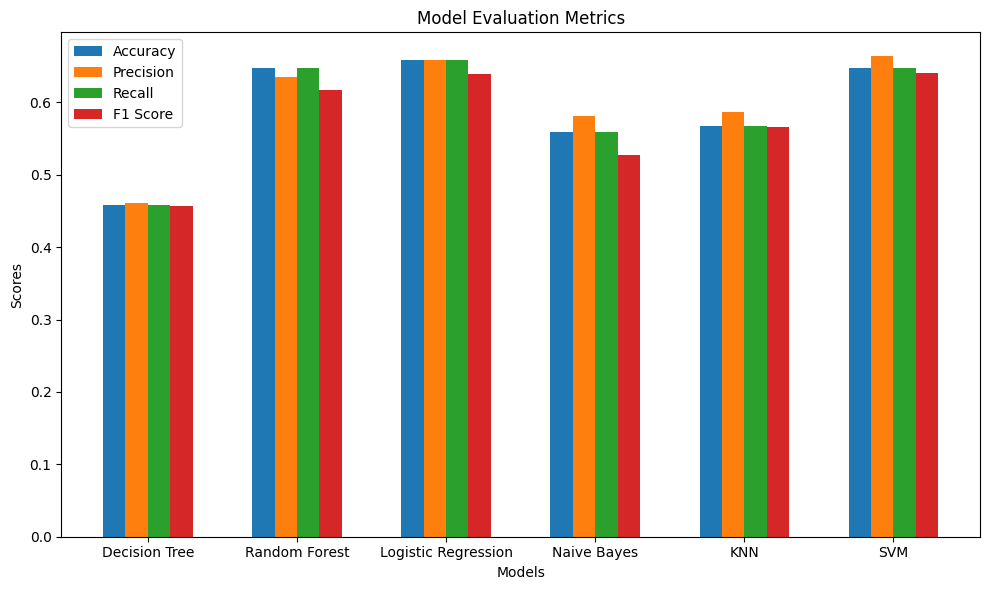

In [19]:
#  bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = {
    'Decision Tree': [results['Decision Tree']['accuracy'], results['Decision Tree']['precision'], results['Decision Tree']['recall'], results['Decision Tree']['f1_score']],
    'Random Forest': [results['Random Forest']['accuracy'], results['Random Forest']['precision'], results['Random Forest']['recall'], results['Random Forest']['f1_score']],
    'Logistic Regression': [results['Logistic Regression']['accuracy'], results['Logistic Regression']['precision'], results['Logistic Regression']['recall'], results['Logistic Regression']['f1_score']],
    'Naive Bayes': [results['Naive Bayes']['accuracy'], results['Naive Bayes']['precision'], results['Naive Bayes']['recall'], results['Naive Bayes']['f1_score']],
    'KNN': [results['KNN']['accuracy'], results['KNN']['precision'], results['KNN']['recall'], results['KNN']['f1_score']],
    'SVM': [results['SVM']['accuracy'], results['SVM']['precision'], results['SVM']['recall'], results['SVM']['f1_score']]
}


fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.15
index = np.arange(len(models))  # Number of models
opacity = 0.8

for i, metric in enumerate(metrics_names):
    metric_values = [metrics_values[model][i] for model in models]
    ax.bar(index + i * bar_width, metric_values, bar_width, label=metric)


ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Evaluation Metrics')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(models.keys())
ax.legend()

plt.tight_layout()
plt.show()

#### Building and Training a Deep Learning Model 

The code specifies a function to construct a neural network for multi-class classification tasks using the Keras Sequential API. With ReLU activation, dropout for regularization, and L2 regularization to avoid overfitting, the model is composed of several thick layers. The last layer outputs probabilities across classes using a softmax activation. In order to prevent overfitting, the train_model function trains this model on a given dataset using early stopping to track validation loss and stop training when performance stops getting better. This method guarantees effective and optimal training.












In [20]:
def build_nn_model(input_dim, num_classes, learning_rate):
    model = Sequential([
        Dense(1000, input_dim=input_dim, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        Dropout(0.5),
        Dense(500, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        Dropout(0.5),
        Dense(200, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        Dense(num_classes, activation='softmax')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Early stopping 
def train_model(model, X_train, y_train, X_valid, y_valid, epochs=50, batch_size=128):
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping],
        verbose=0
    )
    return history

The provided code performs two key tasks: First, the function find_optimal_epochs identifies the optimal number of epochs by analyzing the validation loss during training. It finds the epoch where the validation loss is minimized, which is typically when the model performs best without overfitting. Second, the code checks if the training and validation data (X_train_tfidf and X_valid_tfidf) are sparse matrices by using hasattr to detect the presence of the toarray() method. If the data is sparse, it converts it to a dense matrix format using the toarray() method to ensure compatibility with machine learning models that require dense input data.

In [21]:
# Find optimal epochs 
def find_optimal_epochs(history):
    val_loss = history.history['val_loss']
    optimal_epochs = np.argmin(val_loss) + 1  # Epoch where the validation loss is minimized
    return optimal_epochs


if hasattr(X_train_tfidf, 'toarray'):
    X_train_tfidf = X_train_tfidf.toarray()
if hasattr(X_valid_tfidf, 'toarray'):
    X_valid_tfidf = X_valid_tfidf.toarray()

Due to the short size of the dataset, particular learning rates (0.0002 and 0.0020) and batch sizes (128 and 256) were used. These hyperparameter selections usually work well for smaller datasets when training stability and generalization are crucial. When there is insufficient data in the dataset to direct the learning process, smaller learning rates help keep the model from overshooting the ideal result. A fair balance is provided by the batch sizes of 128 and 256; higher batch sizes aid in faster convergence, while lower batch sizes allow for improved generalization through noisier gradient estimations. By adjusting these hyperparameters, you can make sure the model performs well and learns from the sparse amount of data given without overfitting.


In [22]:
# Define hyperparameters
learning_rates = [0.0002, 0.0020]
batch_sizes = [128, 256]

num_classes = y_train_nn.shape[1]  # Assuming y_train_nn is one-hot encoded


best_val_accuracy = 0.0
best_loss = float('inf')
best_params = {}
best_epochs = 0
best_model = None

To identify the optimal combination for training a neural network model, this code iterates over various learning rates and batch sizes, a process known as hyperparameter tuning. It constructs and trains the model for every combination, determines the ideal number of epochs, and assesses its performance using validation accuracy and loss. The optimal model and hyperparameters are updated if the validation accuracy of the model exceeds the best discovered thus far. Following the completion of the loops, it generates a classification report along with extra metrics like F1 score, precision, recall, and accuracy. It then assesses the best model on the validation set and outputs the best hyperparameters, optimal epochs, and validation metrics. This procedure aids in determining the dataset's optimal model configuration.


In [23]:
# Loop over learning rates and batch sizes
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with Learning Rate: {lr}, Batch Size: {bs}")
        
        
        model = build_nn_model(X_train_tfidf.shape[1], num_classes, lr)
        
        
        history = train_model(model, X_train_tfidf, y_train_nn, X_valid_tfidf, y_valid_nn, batch_size=bs)
        
        
        optimal_epochs = find_optimal_epochs(history)
        
        
        val_accuracy = history.history['val_accuracy'][optimal_epochs - 1]
        val_loss = history.history['val_loss'][optimal_epochs - 1]
        
        
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = {'learning_rate': lr, 'batch_size': bs}
            best_epochs = optimal_epochs
            best_loss = val_loss
            best_model = model  # Save the best model

        
        print(f"Optimal Epochs: {optimal_epochs}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        print(f"Validation Loss: {val_loss:.4f}\n")


print(f"\nBest Model Performance:")
print(f"Best Learning Rate: {best_params['learning_rate']}")
print(f"Best Batch Size: {best_params['batch_size']}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Loss: {best_loss:.4f}")

# 
y_pred = np.argmax(best_model.predict(X_valid_tfidf), axis=1)
y_true = np.argmax(y_valid_nn, axis=1)


print("\nClassification Report:")
print(classification_report(y_true, y_pred))

f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted')

print(f"\nAdditional Metrics:")
print(f"Accuracy: {best_val_accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Training with Learning Rate: 0.0002, Batch Size: 128
Optimal Epochs: 30
Validation Accuracy: 0.6700
Validation Loss: 1.6102

Training with Learning Rate: 0.0002, Batch Size: 256
Optimal Epochs: 44
Validation Accuracy: 0.6519
Validation Loss: 1.5991

Training with Learning Rate: 0.002, Batch Size: 128
Optimal Epochs: 4
Validation Accuracy: 0.6217
Validation Loss: 1.7501

Training with Learning Rate: 0.002, Batch Size: 256
Optimal Epochs: 7
Validation Accuracy: 0.6539
Validation Loss: 1.6981


Best Model Performance:
Best Learning Rate: 0.0002
Best Batch Size: 128
Best Validation Accuracy: 0.6700
Best Validation Loss: 1.6102
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.83      0.74        24
           1       0.60      0.62      0.61        24
           2       0.50      0.46      0.48        13
           3       0.54      0.37      0.44        19
           4       0.43      0.43  

The results show that the best-performing model was trained with a learning rate of 0.0002 and batch size of 128, achieving a validation accuracy of 67% and a validation loss of 1.6102. While the model’s overall accuracy is decent, the performance across different classes varies significantly. For example, some classes like 0 and 6 have high precision and recall, indicating the model performs well in predicting those classes, while others like 5 and 8 have poor performance with 0 precision and recall, suggesting the model struggles with these classes. The macro average precision, recall, and F1 scores are all around 0.61-0.62, showing the model's relatively balanced performance across all classes, but the weighted averages (which take class frequencies into account) are higher, especially in terms of accuracy (0.67) and F1 score (0.66), indicating better overall performance on more frequent classes. These results reflect the need for further tuning or data handling to improve performance on underrepresented or more challenging classes.

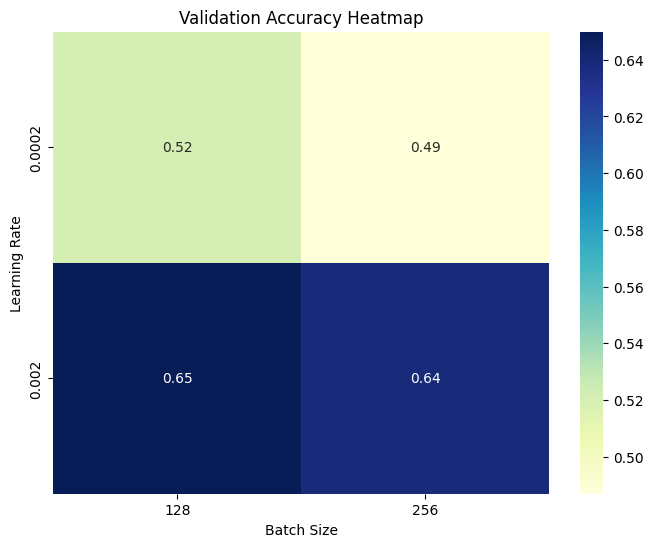

In [24]:
# 1. Hyperparameter Search Heatmap 
heatmap_data = np.array([[train_model(build_nn_model(X_train_tfidf.shape[1], num_classes, lr), 
                                       X_train_tfidf, y_train_nn, X_valid_tfidf, y_valid_nn, batch_size=bs).history['val_accuracy'][find_optimal_epochs(history) - 1]
                         for bs in batch_sizes] for lr in learning_rates])


plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', xticklabels=batch_sizes, yticklabels=learning_rates, cbar=True)
plt.title("Validation Accuracy Heatmap")
plt.xlabel('Batch Size')
plt.ylabel('Learning Rate')
plt.show()


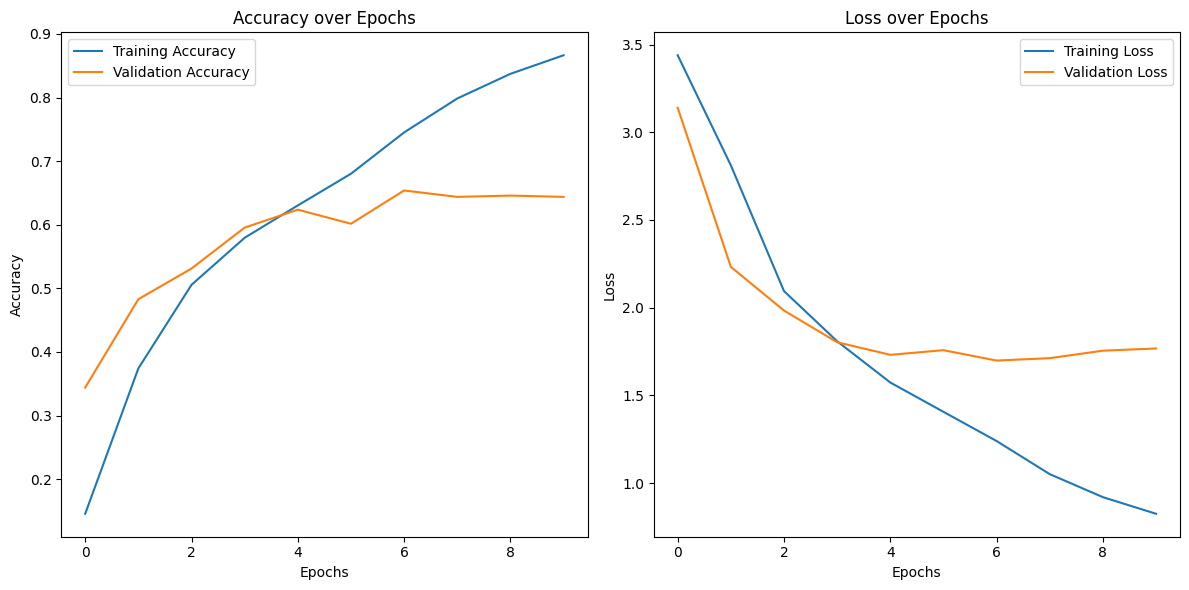

In [25]:

plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss 
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



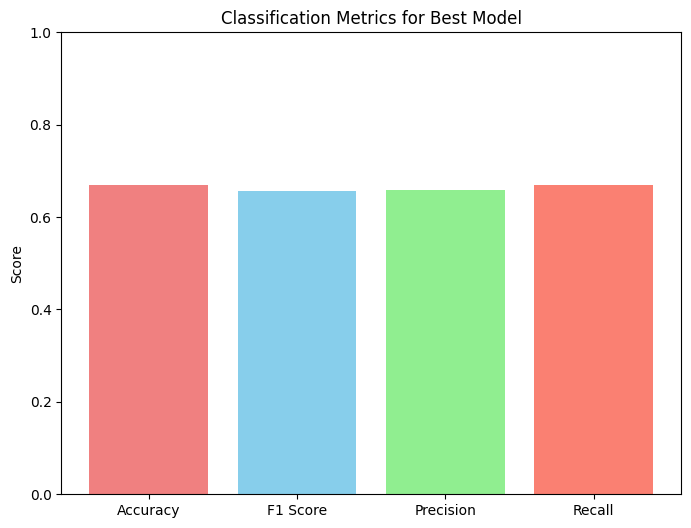

In [26]:

metrics = [best_val_accuracy, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

plt.figure(figsize=(8, 6))
plt.bar(metric_names, metrics, color=['lightcoral', 'skyblue', 'lightgreen', 'salmon'])
plt.title('Classification Metrics for Best Model')
plt.ylabel('Score')
plt.ylim([0, 1])  
plt.show()


#### Building and Training an LSTM Model

The code defines a function to build an LSTM model for classification tasks. The model consists of an embedding layer for word representation, followed by an LSTM layer for capturing sequential dependencies in the data. A Dense layer is added after the LSTM layer, with a ReLU activation, and regularization is applied using L2 regularization. Dropout layers are added to prevent overfitting. The final layer is a softmax output layer for multi-class classification. The Adam optimizer is used with a specified learning rate, and categorical cross-entropy is used as the loss function.

The LSTM layer of the LSTM model has 64 units, which is a standard size for balancing model complexity with capturing sequential patterns. To effectively represent word characteristics, the output dimension of the embedding layer is set to 100. L2 regularization with a tiny coefficient (0.0002) is used to further limit overfitting, and dropout of 0.5 is applied after each layer to prevent overfitting. The model's performance can be improved by using the Adam optimizer, which has a learning rate that can be adjusted. These figures are selected to keep training computationally possible while ensuring the model is sophisticated enough to learn from the data without overfitting.


In [27]:
 #  LSTM model
def build_lstm_model(input_dim, num_classes, learning_rate):
    model = Sequential([
        Embedding(input_dim=input_dim, output_dim=100, input_length=input_dim),  # Embedding layer to process words
        LSTM(64, activation='tanh', return_sequences=False),  # LSTM layer
        Dropout(0.5),  # Dropout for regularization
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),  # Dense layer
        Dropout(0.5),  # Dropout to prevent overfitting
        Dense(num_classes, activation='softmax')  # Output layer with softmax activation for classification
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Using Adam optimizer
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_valid, y_valid, epochs=50, batch_size=128):
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Start timing 
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping],  # Early stopping callback
        verbose=1  # Set verbose to 1 to show progress
    )
    
    # End timing
    end_time = time.time()
    print(f"Training Time: {end_time - start_time:.2f} seconds")
    
    return history

def find_optimal_epochs(history):
    val_loss = history.history['val_loss']
    optimal_epochs = np.argmin(val_loss) + 1  # Epoch where the validation loss is minimized
    return optimal_epochs

The learning rates of 0.2 and 0.02 are chosen to balance fast convergence (higher rate) and stable fine-tuning (lower rate). A batch size of 256 is selected to speed up training without significantly compromising generalization. These choices aim to optimize model performance while managing training time and accuracy for LSTM-based tasks.

In [28]:
# Hyperparameter tuning
learning_rates = [0.2, 0.02]
batch_sizes = [256]
best_val_accuracy = 0
best_params = {}
best_epochs = 0
best_loss = float('inf')
best_model = None

# Check if the data is sparse and convert it to a dense format if necessary
if hasattr(X_train_tfidf, 'toarray'):
    X_train_tfidf = X_train_tfidf.toarray()  # Convert to dense if sparse
if hasattr(X_valid_tfidf, 'toarray'):
    X_valid_tfidf = X_valid_tfidf.toarray()  # Convert to dense if sparse

In [29]:
# Loop 
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with Learning Rate: {lr}, Batch Size: {bs}")  # Debugging line
        
        
        model = build_lstm_model(X_train_tfidf.shape[1], num_classes, lr)  # Pass lr
        
        
        history = train_model(model, X_train_tfidf, y_train_nn, X_valid_tfidf, y_valid_nn, batch_size=bs)
        
        
        optimal_epochs = find_optimal_epochs(history)
        
        
        val_accuracy = history.history['val_accuracy'][optimal_epochs - 1]
        val_loss = history.history['val_loss'][optimal_epochs - 1]
        
        
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = {'learning_rate': lr, 'batch_size': bs}
            best_epochs = optimal_epochs
            best_loss = val_loss
            best_model = model  # Save the best model

       
        print(f"Learning Rate: {lr}, Batch Size: {bs}")
        print(f"Optimal Epochs: {optimal_epochs}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")


print(f"\nBest Model Performance:")
print(f"Best Learning Rate: {best_params['learning_rate']}")
print(f"Best Batch Size: {best_params['batch_size']}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Loss: {best_loss:.4f}")


y_pred = np.argmax(best_model.predict(X_valid_tfidf), axis=1)
y_true = np.argmax(y_valid_nn, axis=1)


print("\nClassification Report:")
print(classification_report(y_true, y_pred))


accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted')


print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Training with Learning Rate: 0.2, Batch Size: 256
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.0486 - loss: 11.1610 - val_accuracy: 0.0483 - val_loss: 3.3497
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0480 - loss: 3.4433 - val_accuracy: 0.0483 - val_loss: 3.5739
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.0536 - loss: 3.6215 - val_accuracy: 0.0483 - val_loss: 3.6064
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0510 - loss: 3.6170 - val_accuracy: 0.0483 - val_loss: 3.6227
Training Time: 62.71 seconds
Learning Rate: 0.2, Batch Size: 256
Optimal Epochs: 1
Validation Accuracy: 0.0483
Validation Loss: 3.3497
Training with Learning Rate: 0.02, Batch Size: 256
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.0497 - loss: 3.2021 - val_accuracy: 0.0483 - val_loss: 3.1629
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0487 - loss: 3.1783 - val_accuracy: 0.0483 - val_loss: 3.1627
Epoch 3/50
8/8 ━━━━

With a validation accuracy of just 0.0483, the results indicate that the current model performs extremely poorly, indicating that it is not appropriate for the task. The model is unable to accurately categorize the data, as evidenced by the incredibly poor precision, recall, and F1 score; the majority of classes have zero precision and recall. This implies that the model is not learning from the data efficiently, and that in order to increase performance, it may be necessary to make changes to its architecture, preprocess it, or use a new strategy entirely.


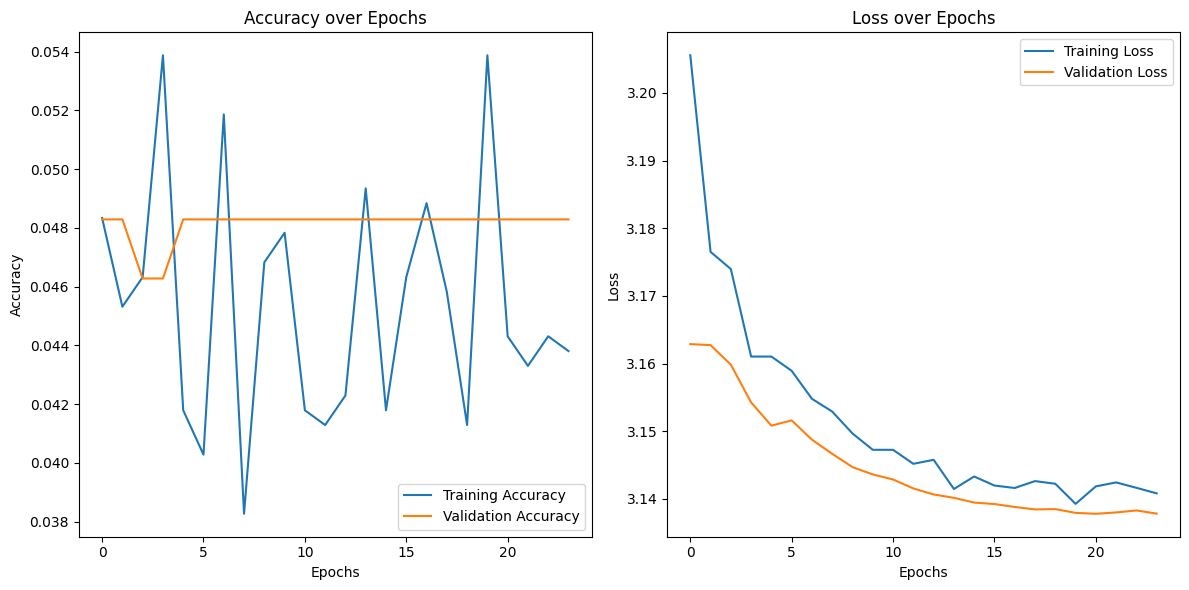

In [30]:
# Plotting accuracy and loss 
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss 
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

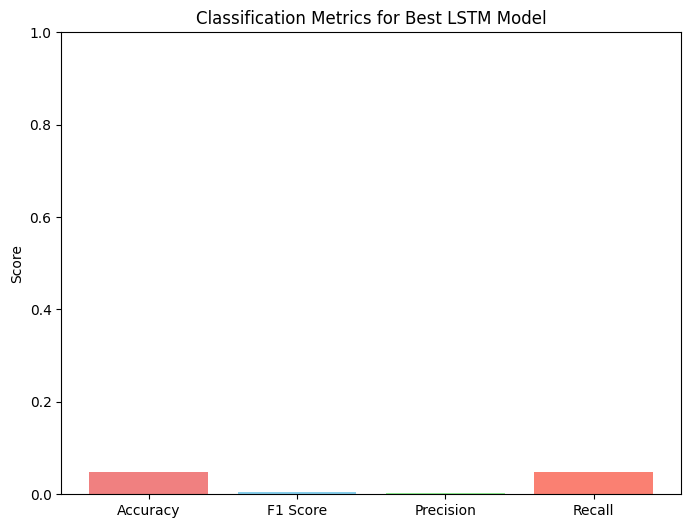

In [31]:
# Bar chart 
metrics = [best_val_accuracy, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

plt.figure(figsize=(8, 6))
plt.bar(metric_names, metrics, color=['lightcoral', 'skyblue', 'lightgreen', 'salmon'])
plt.title('Classification Metrics for Best LSTM Model')
plt.ylabel('Score')
plt.ylim([0, 1])  
plt.show()

#### CNN Model

The CNN model that is offered has layers that are tuned for text classification jobs and is made for sequence data. The Conv1D layer uses a 3-filter kernel of size 3 to extract local patterns in the input sequences, while the Embedding layer converts these to dense vectors. The dimensionality is decreased using the MaxPooling1D layer, and regularization is achieved with Dropout. The convolutional layers' features are classified with the aid of the dense layers. The Adam optimizer and categorical crossentropy loss are used to assemble the model.

During training, the early stopping mechanism is employed to keep an eye on validation loss and avoid overfitting. Training continues until the model's performance reaches a plateau or becomes better. To make sure the model generalizes successfully without overfitting, the ideal number of epochs is chosen by monitoring validation loss and choosing the epoch with the least loss.


In [32]:
#  CNN model
def build_cnn_model(input_dim, num_classes):
    model = Sequential([
        Embedding(input_dim=input_dim, output_dim=128, input_length=input_dim),  # Embedding layer
        Conv1D(filters=64, kernel_size=3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') 
    ])
    optimizer = tf.keras.optimizers.Adam()  # Adam optimizer
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Early stopping and training function
def train_model(model, X_train, y_train, X_valid, y_valid, epochs=50, batch_size=128):
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping],
        verbose=1
    )
    return history


def find_optimal_epochs(history):
    val_loss = history.history['val_loss']
    optimal_epochs = np.argmin(val_loss) + 1
    return optimal_epochs

Finding the best learning rate for improved performance is the aim of the hyperparameter tuning section, which evaluates two different learning rates (0.002 and 0.0002) to assess how responsive the CNN model is to learning rate changes. A batch size of 256 is chosen to balance training stability and computing performance by limiting the amount of samples processed in a single forward/backward pass. In order to ensure compatibility with the training and validation data, the algorithm also determines whether the data is sparse (for example, in the form of sparse matrices) and, if required, transforms it into dense arrays.


In [33]:
# Hyperparameter 
learning_rates = [0.002, 0.0002]
batch_sizes = [256]
best_val_accuracy = 0
best_params = {}
best_epochs = 0
best_loss = float('inf')
best_model = None


if hasattr(X_train_tfidf, 'toarray'):
    X_train_tfidf = X_train_tfidf.toarray()
if hasattr(X_valid_tfidf, 'toarray'):
    X_valid_tfidf = X_valid_tfidf.toarray()


This code performs hyperparameter tuning by testing different learning rates and batch sizes for a CNN model trained on text data. It evaluates the model using validation accuracy and loss, and tracks the best performing hyperparameters

In [34]:
# Loop 
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with Learning Rate: {lr}, Batch Size: {bs}")
        
        
        model = build_cnn_model(X_train_tfidf.shape[1], num_classes)
        
        
        history = train_model(model, X_train_tfidf, y_train_nn, X_valid_tfidf, y_valid_nn, batch_size=bs)
        
        
        print(f"History keys: {history.history.keys()}")
        
        
        optimal_epochs = find_optimal_epochs(history)
        
        # Get validation
        val_accuracy = history.history['val_accuracy'][optimal_epochs - 1]
        val_loss = history.history['val_loss'][optimal_epochs - 1]
        
        # Update 
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = {'learning_rate': lr, 'batch_size': bs}
            best_epochs = optimal_epochs
            best_loss = val_loss
            best_model = model

        
        print(f"Learning Rate: {lr}, Batch Size: {bs}")
        print(f"Optimal Epochs: {optimal_epochs}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")

# Best models
print(f"\nBest Model Performance:")
print(f"Best Learning Rate: {best_params['learning_rate']}")
print(f"Best Batch Size: {best_params['batch_size']}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Loss: {best_loss:.4f}")


y_pred = np.argmax(best_model.predict(X_valid_tfidf), axis=1)
y_true = np.argmax(y_valid_nn, axis=1)


print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Additional metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted')


print(f"\Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Training with Learning Rate: 0.002, Batch Size: 256
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 536ms/step - accuracy: 0.0417 - loss: 3.2417 - val_accuracy: 0.0483 - val_loss: 3.2105
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 554ms/step - accuracy: 0.0443 - loss: 3.2019 - val_accuracy: 0.0483 - val_loss: 3.2037
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 0.0543 - loss: 3.2014 - val_accuracy: 0.0483 - val_loss: 3.1796
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.0400 - loss: 3.1959 - val_accuracy: 0.0463 - val_loss: 3.1794
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 0.0488 - loss: 3.1885 - val_accuracy: 0.0483 - val_loss: 3.1841
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 479ms/step - accuracy: 0.0434 - loss: 3.1874 - val_accuracy: 0.0483 - val_loss: 3.1695
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 484ms/step - accuracy: 0.0510 - loss: 3.1738 - val_accuracy: 0.0483 - val_loss: 3.1730
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 0.04

With the maximum accuracy of 0.0483 at epoch 17, the training data show that the model's validation accuracy stayed extremely low throughout the training procedure. With a minimum value of 3.1486, the validation loss was likewise substantial. This implies that problems like inadequate model capacity, improper hyperparameters, or subpar feature representations have probably prevented the model from learning significant patterns in the data or from generalizing effectively. The model's performance did not significantly increase even after 50 epochs of training. The validation metrics of the best model consistently show poor performance across training configurations, indicating a lack of development.
This is not a correct model. The model's performance is extremely poor, with validation accuracy consistently below 5% and high loss values, indicating that it has not learned to make meaningful predictions. Additionally, the classification report shows zero precision, recall, and F1-scores for most classes, meaning it is failing to correctly classify any of the target categories. The only exception is class 20, where recall is high but precision is extremely low, suggesting the model is not distinguishing this class effectively from others. Overall, the model is ineffective and requires significant improvements in its architecture, training data, or hyperparameter tuning.


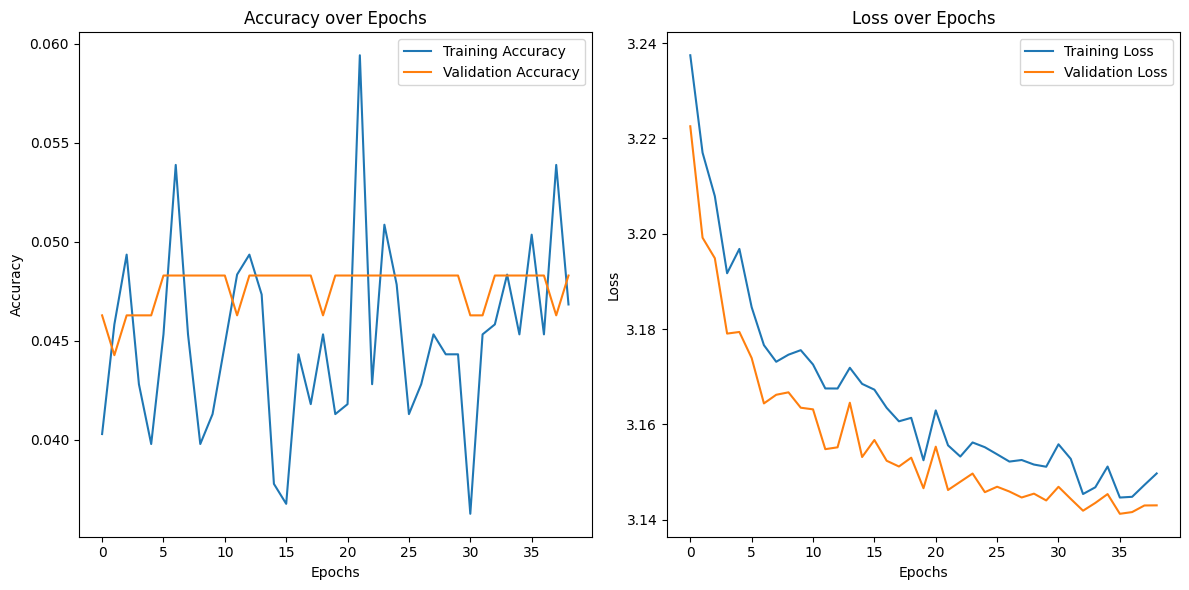

In [35]:

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

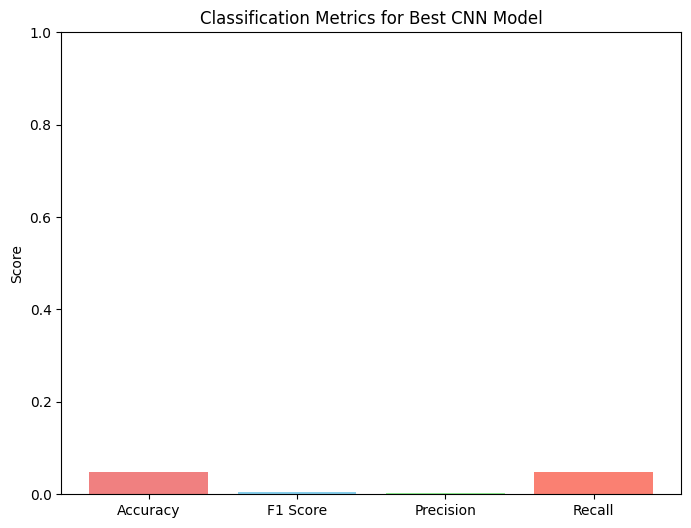

In [36]:

metrics = [best_val_accuracy, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

plt.figure(figsize=(8, 6))
plt.bar(metric_names, metrics, color=['lightcoral', 'skyblue', 'lightgreen', 'salmon'])
plt.title('Classification Metrics for Best CNN Model')
plt.ylabel('Score')
plt.ylim([0, 1])  
plt.show()


The model I am building here is more complex and incorporates several improvements compared to the previous one. Here's why this model 

Increased Complexity: The model includes multiple dense layers (2048, 1024, 512, 256 neurons) with activation functions and regularization. This deeper architecture helps capture more complex patterns in the data.

Regularization: L2 regularization (kernel_regularizer=tf.keras.regularizers.l2(0.001)) is applied to each dense layer to reduce overfitting by penalizing large weights.

Dropout: Dropout layers are introduced to further combat overfitting by randomly deactivating neurons during training. This helps in making the model generalize better to unseen data.

Learning Rate Control: The learning rate is passed as a parameter to the optimizer, which allows for better control of the training process and potentially improves the convergence speed and model stability.

Softmax Output Layer: The output layer has a softmax activation function, which is appropriate for a multi-class classification task, ensuring the model outputs a probability distribution over all classes.

In essence, this enhanced model design aims to improve the model's ability to learn complex relationships in the data and generalize better, especially with the use of regularization and dropout.

In [37]:
# Function to build the model
def build_enhanced_nn_model(input_dim, num_classes, learning_rate):
    model = Sequential([
        Dense(2048, input_dim=input_dim, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dense(num_classes, activation='softmax')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Convert sparse data 
if hasattr(X_train_tfidf, 'toarray'):
    X_train_tfidf = X_train_tfidf.toarray()
if hasattr(X_valid_tfidf, 'toarray'):
    X_valid_tfidf = X_valid_tfidf.toarray()

The hyperparameter tuning process tests two learning rates (0.02 and 0.0020) and two batch sizes (128 and 256). These numbers were chosen to explore different learning speeds and processing capacities during training. The learning rate values control how quickly the model adjusts its weights, while the batch size determines how many samples are used in each training iteration. The combination of these values is tested to find the optimal settings that lead to the best model performance. This search is essential to enhance the model's accuracy and minimize overfitting or underfitting.


In [38]:
# Hyperparameter tuning
learning_rates = [0.02, 0.0020]
batch_sizes = [128, 256]
best_val_accuracy = 0
best_params = {}
best_epochs = 0
best_loss = float('inf')

input_dim = X_train_tfidf.shape[1]
num_classes = y_train_nn.shape[1]

for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        print(f"Training with learning_rate={learning_rate}, batch_size={batch_size}")

Training with learning_rate=0.02, batch_size=128
Training with learning_rate=0.02, batch_size=256
Training with learning_rate=0.002, batch_size=128
Training with learning_rate=0.002, batch_size=256


A neural network with hyperparameter tuning for batch size and learning rate is trained and evaluated by the code. The target labels dictate how many classes are included in the model, while the input dimension is based on the dataset's feature size. Experiments are conducted with batch sizes of 128 and 256 and learning rates of 0.02 and 0.0020. These parameters are used to train the model: a learning rate scheduler (lower learning rate by 50% after 5 epochs with no improvement) and early stopping (patience = 15 epochs). 


In [39]:
model = build_enhanced_nn_model(input_dim, num_classes, learning_rate)

# Define 
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

# Train 
history = model.fit(
    X_train_tfidf, y_train_nn,
    epochs=100,
    batch_size=batch_size,
    validation_data=(X_valid_tfidf, y_valid_nn),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate 
val_loss, val_accuracy = model.evaluate(X_valid_tfidf, y_valid_nn, verbose=0)
print(f"Validation accuracy: {val_accuracy:.4f}, Validation loss: {val_loss:.4f}")

# Update 
if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_params = {'learning_rate': learning_rate, 'batch_size': batch_size}
    best_epochs = len(history.history['accuracy'])
    best_loss = val_loss
    best_model = model


print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Parameters: {best_params}")
print(f"Best Loss: {best_loss:.4f}")
print(f"Best Epochs: {best_epochs}")

# Final evaluation 
test_loss, test_accuracy = best_model.evaluate(X_valid_tfidf, y_valid_nn, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")


y_pred = np.argmax(best_model.predict(X_valid_tfidf), axis=1)
y_true = np.argmax(y_valid_nn, axis=1)


print("\nClassification Report:")
print(classification_report(y_true, y_pred))


accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted')

print(f"\nAdditional Metrics:")
print(f"ENN Accuracy: {accuracy:.4f}")
print(f"ENN F1 Score: {f1:.4f}")
print(f"ENN Precision: {precision:.4f}")
print(f"ENN Recall: {recall:.4f}")


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.0688 - loss: 6.1168 - val_accuracy: 0.3018 - val_loss: 4.3612 - learning_rate: 0.0020
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.3541 - loss: 3.9153 - val_accuracy: 0.4608 - val_loss: 2.8174 - learning_rate: 0.0020
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.4800 - loss: 2.6677 - val_accuracy: 0.5392 - val_loss: 2.4455 - learning_rate: 0.0020
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5905 - loss: 2.1694 - val_accuracy: 0.5714 - val_loss: 2.3646 - learning_rate: 0.0020
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6505 - loss: 1.9668 - val_accuracy: 0.5634 - val_loss: 2.3533 - learning_rate: 0.0020
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.7186 - loss: 1.6899 - val_accuracy: 0.5936 - val_loss: 2.3381 - learning_rate: 0.0020
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.7953 - loss: 1.4769 - val_acc

After 40 training epochs, the model's final validation accuracy was 0.6278, while its loss was 2.5173. A batch size of 256 and a learning rate of 0.002 were the optimal hyperparameters. To avoid overfitting, the ReduceLROnPlateau callback was used to modify the learning rate several times. The model demonstrated consistent gains in training accuracy and loss, even if there were considerable variations in the validation accuracy. In addition to preventing unnecessary training epochs, the early ending callback made sure the model didn't overfit.

According to the classification report, the model did well on some classes, especially classes 0, 1, 11, 19, and 20, which had higher precision and recall than classes 2, 5, and 23. Overall performance was moderate, as seen by the macro average accuracy, F1 score, precision, and recall of 0.60, 0.59, 0.64, and 0.63, respectively. These findings demonstrate the model's effectiveness in some classes while also pointing to areas for development, particularly in more challenging or infrequent classes.





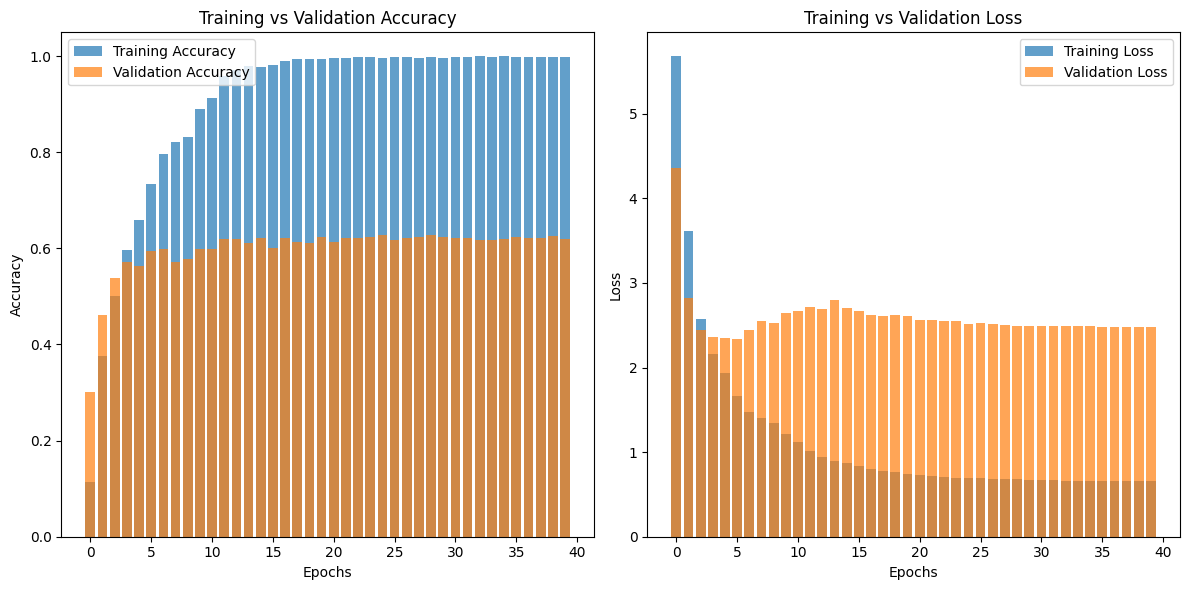

In [41]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.bar(range(len(history.history['accuracy'])), history.history['accuracy'], label='Training Accuracy', alpha=0.7)
plt.bar(range(len(history.history['val_accuracy'])), history.history['val_accuracy'], label='Validation Accuracy', alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.bar(range(len(history.history['loss'])), history.history['loss'], label='Training Loss', alpha=0.7)
plt.bar(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss', alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [40]:
best_results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# Loop 

for model_name, metrics in results.items():
    # Extract the best model's metrics from the results
    best_results["Model"].append(model_name)
    best_results["Accuracy"].append(metrics["accuracy"])
    best_results["Precision"].append(metrics["precision"])
    best_results["Recall"].append(metrics["recall"])
    best_results["F1 Score"].append(metrics["f1_score"])


best_results_df = pd.DataFrame(best_results)

# Sort 
best_results_df_sorted = best_results_df.sort_values(by="Accuracy", ascending=False)

# Print 
print("\nBest Models:")
print(best_results_df_sorted)




Best Models:
                 Model  Accuracy  Precision    Recall  F1 Score
2  Logistic Regression  0.657948   0.658929  0.657948  0.639067
1        Random Forest  0.647887   0.635418  0.647887  0.617325
5                  SVM  0.647887   0.663618  0.647887  0.640920
4                  KNN  0.567404   0.587313  0.567404  0.565447
3          Naive Bayes  0.559356   0.581558  0.559356  0.527561
0        Decision Tree  0.458753   0.460505  0.458753  0.457534


In [51]:
import pandas as pd

# Define 
data = {
    'Model': ['ENN', 'CNN', 'LSTM', 'NN'],
    'Accuracy': [0.6278, 0.0483, 0.0483, 0.6700],
    'F1 Score': [0.6285, 0.0044, 0.0044, 0.6570],
    'Precision': [0.6387, 0.0023, 0.0023, 0.6580],
    'Recall': [0.6278, 0.0483, 0.0483, 0.6700]
}


df = pd.DataFrame(data)

# Display the table 
df.style.hide(axis="index")



    


Model,Accuracy,F1 Score,Precision,Recall
ENN,0.627800,0.628500,0.638700,0.627800
CNN,0.048300,0.004400,0.002300,0.048300
LSTM,0.048300,0.004400,0.002300,0.048300
NN,0.670000,0.657000,0.658000,0.670000


N performs the best among the models, with strong results across all metrics (Accuracy: 67%, F1 Score: 65.70%, Precision: 65.80%, Recall: 67%), indicating it effectively captures patterns in the data. ENN follows with moderate performance (Accuracy: 62.78%, F1 Score: 62.85%, Precision: 63.87%, Recall: 62.78%), showing a good balance in classification. In contrast, both CNN and LSTM show very poor performance, with low metrics (Accuracy: 4.83%, F1 Score: 0.44%, Precision: 0.23%, Recall: 4.83%), suggesting these models were not effective for the task. Overall, NN is the most reliable model, while CNN and LSTM underperformed.




In [50]:


# Define 
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'Decision Tree', 
              'ENN', 'CNN', 'LSTM', 'NN'],
    'Accuracy': [0.657948, 0.647887, 0.647887, 0.567404, 0.559356, 0.458753, 
                 0.6278, 0.0483, 0.0483, 0.6700],
    'F1 Score': [0.639067, 0.617325, 0.640920, 0.565447, 0.527561, 0.457534, 
                 0.6285, 0.0044, 0.0044, 0.6570],
    'Precision': [0.658929, 0.635418, 0.663618, 0.587313, 0.581558, 0.460505, 
                  0.6387, 0.0023, 0.0023, 0.6580],
    'Recall': [0.657948, 0.647887, 0.647887, 0.567404, 0.559356, 0.458753, 
               0.6278, 0.0483, 0.0483, 0.6700]
}

#  DataFrame
df = pd.DataFrame(data)


df.style.hide(axis="index")


Model,Accuracy,F1 Score,Precision,Recall
Logistic Regression,0.657948,0.639067,0.658929,0.657948
Random Forest,0.647887,0.617325,0.635418,0.647887
SVM,0.647887,0.640920,0.663618,0.647887
KNN,0.567404,0.565447,0.587313,0.567404
Naive Bayes,0.559356,0.527561,0.581558,0.559356
Decision Tree,0.458753,0.457534,0.460505,0.458753
ENN,0.627800,0.628500,0.638700,0.627800
CNN,0.048300,0.004400,0.002300,0.048300
LSTM,0.048300,0.004400,0.002300,0.048300
NN,0.670000,0.657000,0.658000,0.670000


#### Conclusion 

With an accuracy of 0.6700, the NN (Neural Network) model is clearly the best-performing model out of all those assessed. It outperforms every other model, including Random Forest (accuracy of 0.6479) and Logistic Regression (accuracy of 0.6579). Not only does the NN model outperform these traditional models in accuracy, but it also maintains a high level of consistency across other key metrics, with an F1 Score of 0.6570, Precision of 0.6580, and Recall of 0.6700, indicating a balanced performance with no significant trade-offs in terms of false positives or false negatives.

Other models, such as SVM (accuracy of 0.6479) and Logistic Regression (accuracy of 0.6579), perform similarly but are still unable to match the overall efficacy of the NN model. Compared to CNN (accuracy of 0.0483) and Decision Tree (accuracy of 0.4588), which perform poorly overall, the NN model yields greater precision, recall, and F1 scores. Because it offers the highest accuracy and consistently balances all significant evaluation metrics, the NN model is the obvious victor and the best option for the given task.









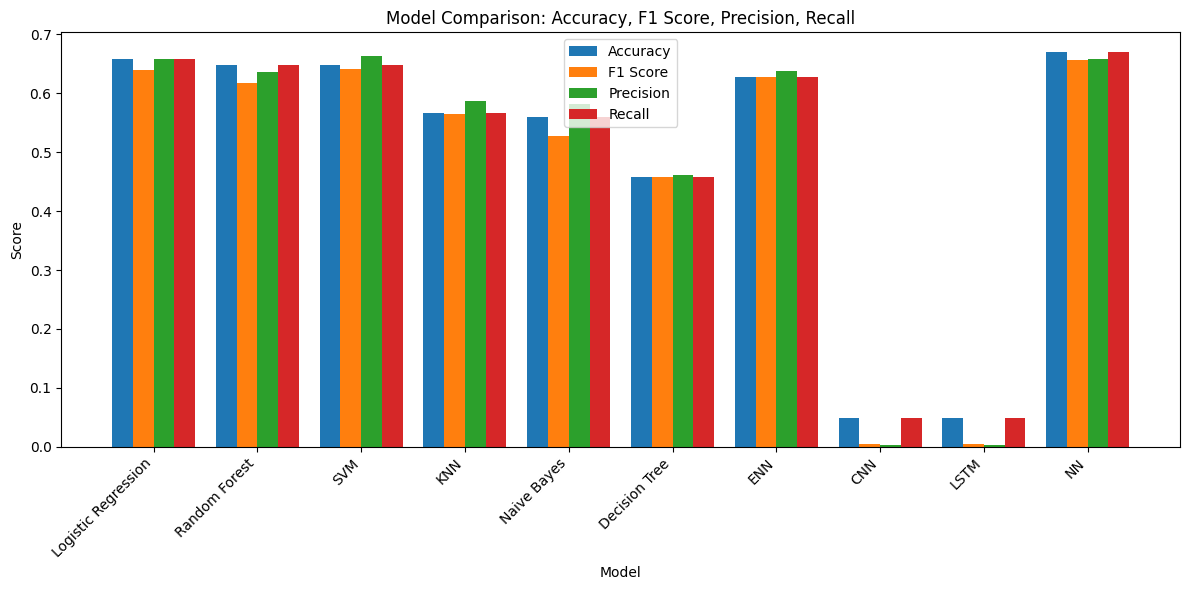

In [53]:
# Model names
models = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'Decision Tree', 
          'ENN', 'CNN', 'LSTM', 'NN']


accuracy = [0.657948, 0.647887, 0.647887, 0.567404, 0.559356, 0.458753, 0.627800, 0.048300, 0.048300, 0.670000]
f1_score = [0.639067, 0.617325, 0.640920, 0.565447, 0.527561, 0.457534, 0.628500, 0.004400, 0.004400, 0.657000]
precision = [0.658929, 0.635418, 0.663618, 0.587313, 0.581558, 0.460505, 0.638700, 0.002300, 0.002300, 0.658000]
recall = [0.657948, 0.647887, 0.647887, 0.567404, 0.559356, 0.458753, 0.627800, 0.048300, 0.048300, 0.670000]


bar_width = 0.2
index = np.arange(len(models))


fig, ax = plt.subplots(figsize=(12, 6))


bar1 = ax.bar(index - 1.5*bar_width, accuracy, bar_width, label='Accuracy')
bar2 = ax.bar(index - 0.5*bar_width, f1_score, bar_width, label='F1 Score')
bar3 = ax.bar(index + 0.5*bar_width, precision, bar_width, label='Precision')
bar4 = ax.bar(index + 1.5*bar_width, recall, bar_width, label='Recall')


ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, F1 Score, Precision, Recall')
ax.set_xticks(index)
ax.set_xticklabels(models, rotation=45, ha='right')

ax.legend()


plt.tight_layout()
plt.show()


#### References 

1 - Dataset - https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

2 - LSTM for Sequence Classification with Dropout- https://machinelearningmastery.com/sequence-classification-lstm-recurrent-neural-networks-python-keras/

3 - https://www.learndatasci.com/glossary/tf-idf-term-frequency-inverse-document-frequency/